In [17]:
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from pathlib import Path


PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "components").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "components").exists():
            PROJECT_ROOT = parent
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))


from components.models import ANFISAdvanced, fcm_initialize


In [18]:
# ---------------------------
# 1) Prepare Iris data (multiclass)
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

HAS_CUDA = torch.cuda.is_available()
if HAS_CUDA:
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def build_iris():
    data = load_iris()
    X = data.data.astype(np.float32)
    y = data.target.astype(np.int64)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)
    return X_scaled, y


X, y = build_iris()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)
n_classes = len(np.unique(y))



In [19]:
# ---------------------------
# 2) Training loop (Gaussian+Sigmoid MFs, multiclass)
# ---------------------------
device = torch.device("cuda" if HAS_CUDA else "cpu")

y_train_tensor = torch.tensor(y_train, dtype=torch.long).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.long).to(device)
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

K = 3
centers_init, spreads_init = fcm_initialize(X_train, K)
s_mode_choice = "alpha_beta"
model = ANFISAdvanced(centers_init, spreads_init, s_mode=s_mode_choice, n_outputs=n_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

n_epochs = 1000
best_loss = float("inf")
best_state = None

for epoch in range(1, n_epochs + 1):
    model.train()
    optimizer.zero_grad()
    logits = model(X_train_tensor)
    loss = loss_fn(logits, y_train_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
    optimizer.step()

    if loss.item() < best_loss:
        best_loss = loss.item()
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 200 == 0 or epoch == 1:
        model.eval()
        with torch.no_grad():
            train_pred = torch.argmax(model(X_train_tensor), dim=1)
            test_pred = torch.argmax(model(X_test_tensor), dim=1)
            train_acc = (train_pred == y_train_tensor).float().mean().item()
            test_acc = (test_pred == y_test_tensor).float().mean().item()
        print(
            f"Epoch {epoch:04d}/{n_epochs}  Loss {loss.item():.4f}  "
            f"Train Acc {train_acc:.3f}  Test Acc {test_acc:.3f}"
        )

if best_state is not None:
    model.load_state_dict(best_state)
model.eval()

with torch.no_grad():
    final_train_logits = model(X_train_tensor)
    final_test_logits = model(X_test_tensor)
    final_train_prob = torch.softmax(final_train_logits, dim=1).cpu().numpy()
    final_test_prob = torch.softmax(final_test_logits, dim=1).cpu().numpy()
    final_train_pred = np.argmax(final_train_prob, axis=1)
    final_test_pred = np.argmax(final_test_prob, axis=1)

train_acc = accuracy_score(y_train, final_train_pred)
test_acc = accuracy_score(y_test, final_test_pred)


def summarize_split(name, y_true, pred):
    total = len(y_true)
    correct = int((pred == y_true).sum())
    wrong = total - correct
    accuracy_rate = correct / total
    error_rate = 1.0 - accuracy_rate
    print(
        f"{name}: accuracy rate {accuracy_rate:.3f} ({correct}/{total} correct points) | "
        f"error {error_rate:.3f} ({wrong} wrong points)"
    )


print("\nFinal Results:")
print(f"Mode: {s_mode_choice}")
summarize_split("Train", y_train, final_train_pred)
summarize_split("Test", y_test, final_test_pred)


Epoch 0001/1000  Loss 1.2924  Train Acc 0.038  Test Acc 0.111
Epoch 0200/1000  Loss 0.6309  Train Acc 0.886  Test Acc 0.822
Epoch 0400/1000  Loss 0.3874  Train Acc 0.905  Test Acc 0.844
Epoch 0600/1000  Loss 0.2241  Train Acc 0.981  Test Acc 0.889
Epoch 0800/1000  Loss 0.1446  Train Acc 0.981  Test Acc 0.911
Epoch 1000/1000  Loss 0.0978  Train Acc 0.981  Test Acc 0.933

Final Results:
Mode: alpha_beta
Train: accuracy rate 0.981 (103/105 correct points) | error 0.019 (2 wrong points)
Test: accuracy rate 0.933 (42/45 correct points) | error 0.067 (3 wrong points)


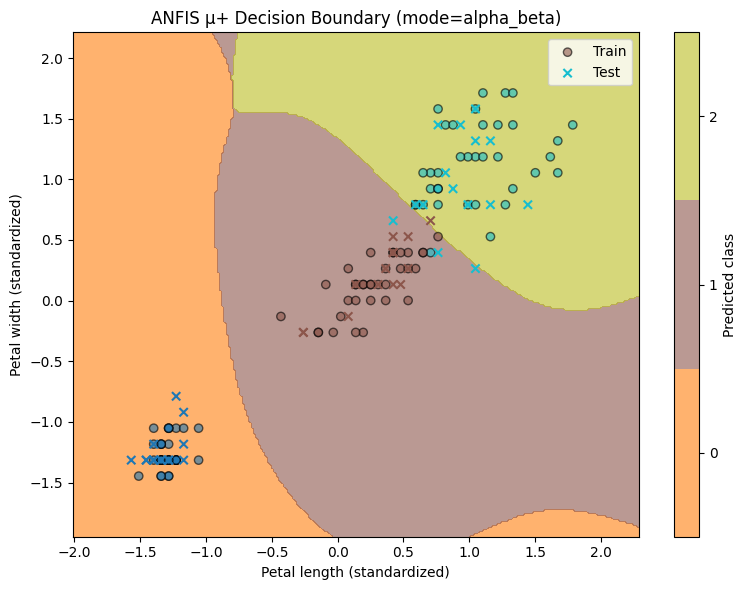

In [20]:
# ---------------------------
# 3) Decision surface on petal features
# ---------------------------
petal_idx = (2, 3)
baseline = X_train.mean(axis=0)

xx, yy = np.meshgrid(
    np.linspace(X_train[:, petal_idx[0]].min() - 0.5, X_train[:, petal_idx[0]].max() + 0.5, 250),
    np.linspace(X_train[:, petal_idx[1]].min() - 0.5, X_train[:, petal_idx[1]].max() + 0.5, 250),
)

grid = np.tile(baseline, (xx.size, 1)).astype(np.float32)
grid[:, petal_idx[0]] = xx.ravel()
grid[:, petal_idx[1]] = yy.ravel()

grid_tensor = torch.from_numpy(grid).to(device)
with torch.no_grad():
    grid_logits = model(grid_tensor)
    grid_pred = torch.argmax(grid_logits, dim=1).cpu().numpy().reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(
    xx,
    yy,
    grid_pred,
    levels=np.arange(n_classes + 1) - 0.5,
    cmap="tab10",
    alpha=0.6,
)
plt.colorbar(ticks=range(n_classes), label="Predicted class")
plt.scatter(
    X_train[:, petal_idx[0]],
    X_train[:, petal_idx[1]],
    c=y_train,
    cmap="tab10",
    edgecolor="k",
    alpha=0.6,
    label="Train",
)
plt.scatter(
    X_test[:, petal_idx[0]],
    X_test[:, petal_idx[1]],
    c=y_test,
    cmap="tab10",
    marker="x",
    label="Test",
)
plt.title(f"ANFIS μ+ Decision Boundary (mode={s_mode_choice})")
plt.xlabel("Petal length (standardized)")
plt.ylabel("Petal width (standardized)")
plt.legend()
plt.tight_layout()
plt.show()